# Multi-Layer Probe Sweep

We run the pairwise depth-ordering linear probe across **all 27 SigLIP encoder layers**
inside LLaVA-OneVision-7B, producing a curve of probe accuracy vs. layer depth.

This confirms that the 80.4% result from layer 16 is not a cherry-picked outlier —
it shows where in the visual encoder depth geometry is encoded and how strongly.

**Drive layout:** same as other notebooks.
**Runtime:** A100 GPU recommended.

Output: `/content/layer_sweep_results.json`

In [1]:
# ── 1. Install ───────────────────────────────────────────────────────────────
!pip install -q transformers>=4.45.0 accelerate>=0.27.0 pillow tqdm scikit-learn

In [2]:
# ── 2. Mount Drive ────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH  = "/content/drive/MyDrive/MindCube/data/raw/MindCube_tinybench.jsonl"
IMAGE_ROOT = "/content/drive/MyDrive/MindCube/data/"
LLAVA_ID   = "/content/drive/MyDrive/models/llava-onevision-qwen2-7b-ov-hf"
DA_PATH    = "/content/drive/MyDrive/models/depth-anything-v2-small-hf"

import pathlib
assert pathlib.Path(DATA_PATH).exists()
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [3]:
# ── 3. Load models ───────────────────────────────────────────────────────────
import torch, gc, json
import numpy as np
from PIL import Image
from pathlib import Path
from transformers import (
    LlavaOnevisionForConditionalGeneration, AutoProcessor,
    pipeline,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# LLaVA
print("Loading LLaVA ...")
llava_processor = AutoProcessor.from_pretrained(LLAVA_ID)
llava_model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    LLAVA_ID, torch_dtype=torch.float16, device_map="auto", attn_implementation="sdpa",
)
llava_model.eval()
llava_processor.image_processor.do_image_splitting = False
vision_tower = llava_model.model.vision_tower
N_LAYERS = len(vision_tower.vision_model.encoder.layers)
print(f"LLaVA loaded. SigLIP has {N_LAYERS} encoder layers.")

# DepthAnything (for depth pseudo-labels)
print("Loading DepthAnything ...")
depth_pipe = pipeline(
    task="depth-estimation", model=DA_PATH,
    device=0 if device == "cuda" else -1,
)
print("All models loaded.")
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Device: cuda
Loading LLaVA ...


The image processor of type `LlavaOnevisionImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/765 [00:00<?, ?it/s]

LLaVA loaded. SigLIP has 26 encoder layers.
Loading DepthAnything ...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


All models loaded.
GPU memory: 16.2 GB


In [4]:
# ── 4. Feature extraction: ALL layers in one forward pass ─────────────────────
# We extract all hidden states at once to avoid N_LAYERS forward passes.

@torch.inference_mode()
def extract_all_layers(pil_image: Image.Image):
    """
    Returns a list of N_LAYERS+1 numpy arrays, one per hidden state.
    hidden_states[0] = patch embeddings (before any encoder layer)
    hidden_states[k] = output of encoder layer k-1  (k=1..N_LAYERS)
    Each array shape: (N_patches, hidden_dim)
    """
    raw = llava_processor.image_processor(images=[pil_image], return_tensors="pt")
    pixel_values = raw.pixel_values
    if isinstance(pixel_values, list):
        pixel_values = pixel_values[0]
    while pixel_values.dim() > 4:
        pixel_values = pixel_values.squeeze(0)
    if pixel_values.dim() == 3:
        pixel_values = pixel_values.unsqueeze(0)
    pixel_values = pixel_values.to(vision_tower.device).to(torch.float16)

    out = vision_tower(pixel_values=pixel_values, output_hidden_states=True)
    # hidden_states is a tuple of length N_LAYERS+1
    return [hs[0].float().cpu().numpy() for hs in out.hidden_states]


@torch.inference_mode()
def get_depth_array(pil_image: Image.Image) -> np.ndarray:
    out = depth_pipe(pil_image)
    return np.array(out["depth"], dtype=np.float32)


# Quick test
_test = Image.new("RGB", (384, 384))
_hs = extract_all_layers(_test)
print(f"Number of hidden states: {len(_hs)}")
print(f"Each hidden state shape: {_hs[0].shape}  (should be (729, 1152))")

Number of hidden states: 27
Each hidden state shape: (729, 1152)  (should be (729, 1152))


In [5]:
# ── 5. Build pair dataset (all layers simultaneously) ─────────────────────────
# For each image: extract depth + all-layer features in ONE forward pass.
# Store per-layer difference vectors and labels.

from tqdm.notebook import tqdm

MAX_IMAGES      = 300
PAIRS_PER_IMAGE = 200
rng = np.random.default_rng(42)

# Load image paths
image_paths = []
with open(DATA_PATH) as f:
    for line in f:
        rec = json.loads(line)
        for rel in rec["images"]:
            p = str(Path(IMAGE_ROOT) / rel)
            if p not in image_paths:
                image_paths.append(p)
            if len(image_paths) >= MAX_IMAGES:
                break
        if len(image_paths) >= MAX_IMAGES:
            break
print(f"Processing {len(image_paths)} images across {N_LAYERS+1} hidden states...")

# layer_X[k] = list of (K, D) diff arrays for layer k
layer_X = [[] for _ in range(N_LAYERS + 1)]
layer_y = [[] for _ in range(N_LAYERS + 1)]

for img_path in tqdm(image_paths):
    try:
        img = Image.open(img_path).convert("RGB")
        depth_arr = get_depth_array(img)          # (H, W)
        all_hs    = extract_all_layers(img)       # list of (729, 1152)
        img.close()

        n_patches = all_hs[0].shape[0]
        grid = int(n_patches ** 0.5)
        depth_grid = np.array(
            Image.fromarray(depth_arr).resize((grid, grid), Image.BILINEAR)
        ).flatten()  # (n_patches,)

        # Sample patch pairs once; reuse indices across all layers
        idxA = rng.integers(0, n_patches, size=PAIRS_PER_IMAGE)
        idxB = rng.integers(0, n_patches, size=PAIRS_PER_IMAGE)
        valid = idxA != idxB
        idxA, idxB = idxA[valid], idxB[valid]
        labels = (depth_grid[idxA] > depth_grid[idxB]).astype(int)

        for k, hs in enumerate(all_hs):
            diff = hs[idxA] - hs[idxB]  # (K, D)
            layer_X[k].append(diff)
            layer_y[k].append(labels)

    except Exception as e:
        print(f"[WARN] {Path(img_path).name}: {e}")
        continue

# Stack
for k in range(N_LAYERS + 1):
    layer_X[k] = np.vstack(layer_X[k]).astype(np.float32)
    layer_y[k] = np.concatenate(layer_y[k])

print(f"Done. Per-layer dataset: {layer_X[0].shape[0]:,} pairs, dim={layer_X[0].shape[1]}")

Processing 300 images across 27 hidden states...


  0%|          | 0/300 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done. Per-layer dataset: 59,922 pairs, dim=1152


In [6]:
# ── 6. Train a probe at every layer ──────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

layer_accs = []

for k in tqdm(range(N_LAYERS + 1), desc="Probing layers"):
    X, y = layer_X[k], layer_y[k]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, train_size=0.8, random_state=42, stratify=y
    )
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    clf = LogisticRegression(max_iter=300, C=1.0, solver="lbfgs", n_jobs=-1)
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    layer_accs.append(acc)

print("\nLayer-by-layer depth ordering accuracy (chance=0.50):")
print(f"{'Layer':>6}  {'Accuracy':>9}")
for k, acc in enumerate(layer_accs):
    marker = " ← layer 16" if k == 16 else (
             " ← embeddings" if k == 0 else (
             f" ← BEST" if acc == max(layer_accs) and k != 16 else ""))
    print(f"{k:>6}  {acc:>9.4f}{marker}")

Probing layers:   0%|          | 0/27 [00:00<?, ?it/s]


Layer-by-layer depth ordering accuracy (chance=0.50):
 Layer   Accuracy
     0     0.7643 ← embeddings
     1     0.7604
     2     0.7727
     3     0.7732
     4     0.7776
     5     0.7898
     6     0.8007
     7     0.8225
     8     0.8349
     9     0.8400
    10     0.8446 ← BEST
    11     0.8405
    12     0.8345
    13     0.8268
    14     0.8194
    15     0.8093
    16     0.8014 ← layer 16
    17     0.7973
    18     0.7891
    19     0.7864
    20     0.7804
    21     0.7765
    22     0.7742
    23     0.7700
    24     0.7670
    25     0.7669
    26     0.7632


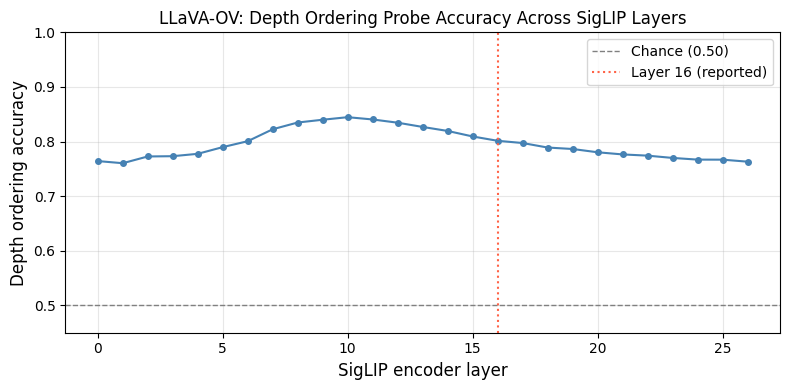

Figure saved to /content/layer_sweep.png


In [7]:
# ── 7. Plot the curve ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(N_LAYERS + 1), layer_accs, marker="o", markersize=4, linewidth=1.5, color="steelblue")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.50)")
ax.axvline(16, color="tomato", linestyle=":", linewidth=1.5, label="Layer 16 (reported)")
ax.set_xlabel("SigLIP encoder layer", fontsize=12)
ax.set_ylabel("Depth ordering accuracy", fontsize=12)
ax.set_title("LLaVA-OV: Depth Ordering Probe Accuracy Across SigLIP Layers", fontsize=12)
ax.set_ylim(0.45, 1.0)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/layer_sweep.png", dpi=150)
plt.show()
print("Figure saved to /content/layer_sweep.png")

In [8]:
# ── 8. Save results + download ────────────────────────────────────────────────
results = {
    "n_images": len(image_paths),
    "pairs_per_image": PAIRS_PER_IMAGE,
    "n_layers": N_LAYERS,
    "chance": 0.5,
    "layer_accuracies": layer_accs,
    "best_layer": int(np.argmax(layer_accs)),
    "best_accuracy": float(max(layer_accs)),
    "layer16_accuracy": layer_accs[16],
}

with open("/content/layer_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Best layer: {results['best_layer']}  accuracy: {results['best_accuracy']:.4f}")
print(f"Layer 16:   {results['layer16_accuracy']:.4f}")

from google.colab import files
files.download("/content/layer_sweep_results.json")
files.download("/content/layer_sweep.png")

Best layer: 10  accuracy: 0.8446
Layer 16:   0.8014


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>